In [113]:
import sys
import csv
import numpy as np
import scipy.io as io
from pathlib import Path

root_dir = Path.cwd().parent.parent
sys.path.insert(0, str(root_dir))
from docs.plot_setup import set_professional_style
plt = set_professional_style(fontsize=12)

In [114]:
ref_res = io.loadmat('results/monolithic_simple.mat')

# Flatten arrays in ref_res
for key in ref_res:
    if isinstance(ref_res[key], np.ndarray):    
        ref_res[key] = ref_res[key].flatten()

### 1. Monolithic Simulation Results

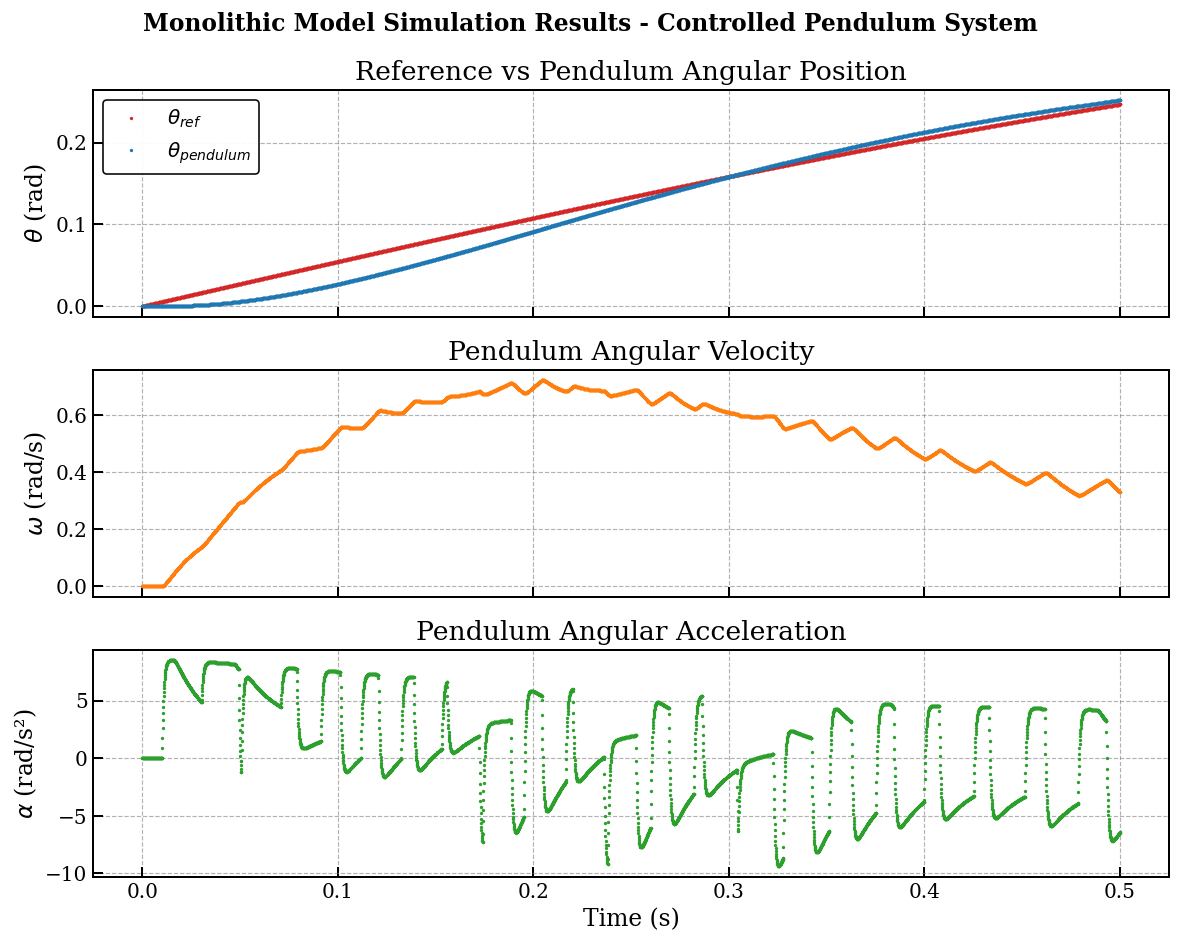

In [115]:
t_vals = ref_res['time']
q_ref = ref_res['reference.q_ref']
q_pendulum = ref_res['pendulum.q']
omega_pendulum = ref_res['pendulum.omega']
alpha_pendulum = ref_res['pendulum.alpha']

style = {'linestyle': 'None', 'marker': 'o', 'markersize': 1}

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Monolithic Model Simulation Results - Controlled Pendulum System', fontweight='bold', fontsize=14)

axs[0].set_title('Reference vs Pendulum Angular Position')
axs[0].plot(t_vals, q_ref, label=r'$\theta_{ref}$', color='tab:red', **style)
axs[0].plot(t_vals, q_pendulum, label=r'$\theta_{pendulum}$', color='tab:blue', **style)
axs[0].set_ylabel(r'$\theta$ (rad)')
axs[0].legend()
axs[0].grid()

axs[1].set_title('Pendulum Angular Velocity')
axs[1].plot(t_vals, omega_pendulum, label=r'$\omega_{pendulum}$', color='tab:orange', **style)
axs[1].set_ylabel(r'$\omega$ (rad/s)')
axs[1].grid()

axs[2].set_title('Pendulum Angular Acceleration')
axs[2].plot(t_vals, alpha_pendulum, label=r'$\alpha_{pendulum}$', color='tab:green', **style)
axs[2].set_ylabel(r'$\alpha$ (rad/s²)')
axs[2].set_xlabel('Time (s)')
axs[2].grid()

plt.tight_layout()
plt.show()

### 2. Co-Simulation Results - Algorithm Comparison

**Result Extraction**

In [116]:
jacobi_dir = Path('results/cs_simple/Jacobi/')
gauss_seidel_dir = Path('results/cs_simple/Gauss-Seidel/')
ijcsa_dir = Path('results/cs_simple/IJCSA/')

dirs = [jacobi_dir, gauss_seidel_dir, ijcsa_dir]
methods = ['Jacobi', 'Gauss-Seidel', 'IJCSA']
dt = [0.02, 0.01, 0.005, 0.001]

ds = {}
for dir, method in zip(dirs, methods):
    ds[method] = {}
    for files in dir.glob('*.csv'):
        print(f'Processing file: {files}')
        dt_value_str = files.stem.split('_')[-1]
        ds[method][dt_value_str] = {}
        with open(files, 'r') as f:
            reader = csv.reader(f)
            header = next(reader)
            units = next(reader)
            data = np.array([list(map(float, row)) for row in reader])
        for i, col_name in enumerate(header):
            ds[method][dt_value_str][col_name] = data[:, i]

Processing file: results/cs_simple/Jacobi/simple_Jacobi_dt_0.005.csv
Processing file: results/cs_simple/Jacobi/simple_Jacobi_dt_0.001.csv
Processing file: results/cs_simple/Jacobi/simple_Jacobi_dt_0.020.csv
Processing file: results/cs_simple/Jacobi/simple_Jacobi_dt_0.010.csv
Processing file: results/cs_simple/Gauss-Seidel/simple_Gauss-Seidel_dt_0.001.csv
Processing file: results/cs_simple/Gauss-Seidel/simple_Gauss-Seidel_dt_0.010.csv
Processing file: results/cs_simple/Gauss-Seidel/simple_Gauss-Seidel_dt_0.020.csv
Processing file: results/cs_simple/Gauss-Seidel/simple_Gauss-Seidel_dt_0.005.csv
Processing file: results/cs_simple/IJCSA/simple_IJCSA_dt_0.005.csv
Processing file: results/cs_simple/IJCSA/simple_IJCSA_dt_0.010.csv
Processing file: results/cs_simple/IJCSA/simple_IJCSA_dt_0.020.csv
Processing file: results/cs_simple/IJCSA/simple_IJCSA_dt_0.001.csv


**Plotting Configuration - Signal Trajectories**

In [117]:
algorithms = list(ds.keys()) + ['Monolithic']
colors = {algorithm: '' for algorithm in algorithms}
colors['Monolithic'] = 'tab:red'
colors['Jacobi'] = 'tab:blue'
colors['Gauss-Seidel'] = 'tab:orange'
colors['IJCSA'] = 'tab:green'

markers = {algorithm: '' for algorithm in algorithms}
markers['Monolithic'] = '.'
markers['Jacobi'] = 'o'
markers['Gauss-Seidel'] = 's'
markers['IJCSA'] = '^'

marker_size = {}
for algorithm in algorithms:
    if algorithm == 'Monolithic':
        marker_size[algorithm] = 1
    else:
        marker_size[algorithm] = 4

labels = {algorithm: '' for algorithm in algorithms}
labels['Monolithic'] = r'Monolithic: DASSL (Modelica)'
labels['Jacobi'] = r'Co-Simulation: Jacobi'
labels['Gauss-Seidel'] = r'Co-Simulation: Gauss-Seidel'
labels['IJCSA'] = r'Co-Simulation: IJCSA'

styles = {}
for algorithm in algorithms:
    styles[algorithm] = {
        'color': colors[algorithm],
        'marker': markers[algorithm],
        'markersize': marker_size[algorithm],
        'label': labels[algorithm],
        'linestyle': 'None'  # Only markers, no lines
    }

In [ ]:
t_ref = ref_res['time']

gs = ds['Gauss-Seidel']
jacobi = ds['Jacobi']
ijcsa = ds['IJCSA']

t_20 = ds['Gauss-Seidel']['0.020'][ 'time']
t_10 = ds['Gauss-Seidel']['0.010']['time']
t_05 = ds['Gauss-Seidel']['0.005']['time']
t_01 = ds['Gauss-Seidel']['0.001']['time']

suptitle_style = {'fontweight': 'bold', 'fontsize': 16}

dts = ['0.020', '0.010', '0.005', '0.001']
titles = ['dt = 0.020 s', 'dt = 0.010 s', 'dt = 0.005 s', 'dt = 0.001 s']

def create_trajectory_plot(signal_monolithic, signal_cs, y_label):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=False)

    for ax, dt, title in zip(axs.flat, dts, titles):
        t = gs[dt]['time']  # or ds['Jacobi'][dt]['time'], they share the grid
        ax.set_title(title, **subtitle_style)

        # reference
        ax.plot(t_ref, ref_res[signal_monolithic], **styles['Monolithic'])
        
        # co-sim algorithms
        ax.plot(t, jacobi[dt][signal_cs], **styles['Jacobi'])
        ax.plot(t, gs[dt][signal_cs], **styles['Gauss-Seidel'])
        ax.plot(t, ijcsa[dt][signal_cs], **styles['IJCSA'])
        
        ax.set_xlabel(r'Time $t$ (s)')
        ax.set_ylabel(y_label)
        ax.minorticks_on()
        ax.grid(True, which='major')
        ax.grid(True, which='minor', alpha=0.3)

    # Add one common legend centered above all subplots
    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=12)

    fig.subplots_adjust(top=0.9)

    plt.subplots_adjust(hspace=0.25, wspace=0.25)

    #plt.tight_layout()
    plt.savefig(f'figures/cs_alg_verification/simple/all/{signal_monolithic.replace(".", "_")}.svg', bbox_inches='tight')
    plt.savefig(f'figures/cs_alg_verification/simple/all/{signal_monolithic.replace(".", "_")}.pdf', bbox_inches='tight')
    plt.show()

**Plotting Configuration: Error Convergence**

In [ ]:
error_styles = {
    'Jacobi': {
        'color': colors['Jacobi'],
        'linestyle': '--',
        'marker': markers['Jacobi'],
        'markersize': 4,
        'label': labels['Jacobi'],
        'linewidth': 2,
    },
    'Gauss-Seidel': {
        'color': colors['Gauss-Seidel'],
        'linestyle': '-.',
        'marker': markers['Gauss-Seidel'],
        'markersize': 4,
        'label': labels['Gauss-Seidel'],
        'linewidth': 2,
    },
    'IJCSA': {
        'color': colors['IJCSA'],
        'linestyle': ':',
        'marker': markers['IJCSA'],
        'markersize': 4,
        'label': labels['IJCSA'],
        'linewidth': 2,
    },
}

def create_error_convergence_plot(monilithic_signal, cs_signal):
    errors = {algorithm: [] for algorithm in ds.keys()}
    for algorithm in ds.keys():
        for dt in dts:
            sim_data = ds[algorithm][dt][cs_signal]
            
            # Interpolate monolithic results to co-simulation time points
            t_cs = ds[algorithm][dt]['time']
            sim_ref_interp = np.interp(t_cs, t_ref, ref_res[monilithic_signal])

            error = np.linalg.norm(sim_ref_interp - sim_data, ord=2) / np.linalg.norm(sim_ref_interp, ord=2)
            errors[algorithm].append(error)
    
    dt_values = []
    for dt in dts:
        dt_values.append(float(dt))

    h_values = np.array(dt_values)
    ref_line = h_values
    ref_line_2nd = h_values**2
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title(f'Error Convergence: {monilithic_signal}', **subtitle_style)
    for algorithm in ds.keys():
        ax.loglog(dt_values, errors[algorithm], **error_styles[algorithm])
    ax.loglog(h_values, ref_line * (errors['Jacobi'][0] / ref_line[0]), 'k--', label=r'$O(\Delta t)$', linewidth=2)
    ax.loglog(h_values, ref_line_2nd * (errors['Jacobi'][0] / ref_line_2nd[0]), 'k:', label=r'$O(\Delta t^2)$', linewidth=2)
    ax.set_xlabel(r'Time Step Size $\Delta t$ (s)')
    ax.set_ylabel(r'Relative Error $\frac{||x_{ref} - x_{cs}||_2}{||x_{ref}||_2}$')
    ax.minorticks_on()
    ax.grid(True, which='major')
    ax.grid(True, which='minor', alpha=0.3)
    ax.legend()
    ax.invert_xaxis()
    plt.savefig(f'figures/cs_alg_verification/simple/convergence/{monilithic_signal.replace(".", "_")}_error.svg', bbox_inches='tight')
    plt.savefig(f'figures/cs_alg_verification/simple/convergence/{monilithic_signal.replace(".", "_")}_error.pdf', bbox_inches='tight')


#### 2.1 Reference

In [ ]:
from demos.ControlledPendulum.verification_algorithm_plots import create_trajectory_plot

monolithic_signal = 'reference.q_ref'
cs_signal = 'reference.q_ref'
y_label = r'Angular Position $\theta_{ref}$ (rad)'
create_trajectory_plot(monolithic_signal, cs_signal, y_label)

IndentationError: expected an indented block after 'for' statement on line 220 (plots.py, line 221)

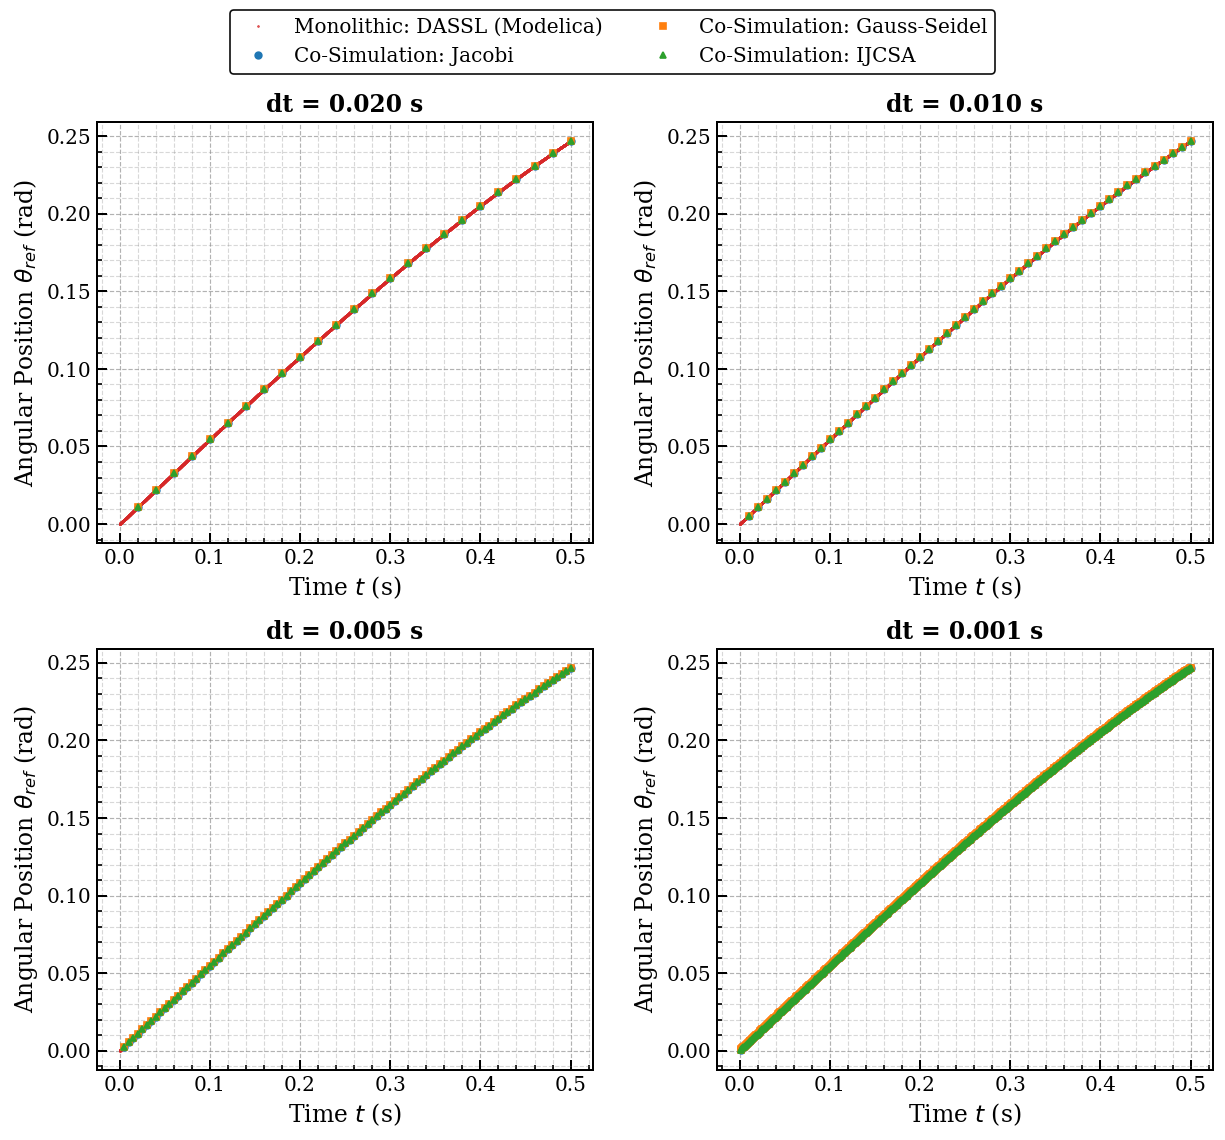

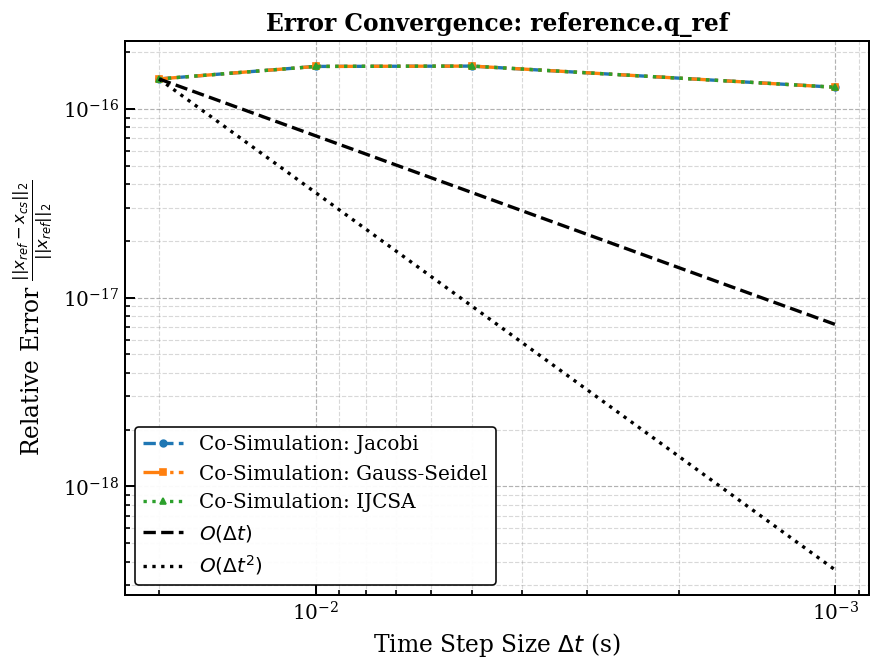

In [147]:
monolithic_signal = 'reference.q_ref'
cs_signal = 'ref.q_ref'
y_label = r'Angular Position $\theta_{ref}$ (rad)'

create_trajectory_plot(monolithic_signal, cs_signal, y_label)
create_error_convergence_plot(monolithic_signal, cs_signal)

#### 2.2 Reference Sensor

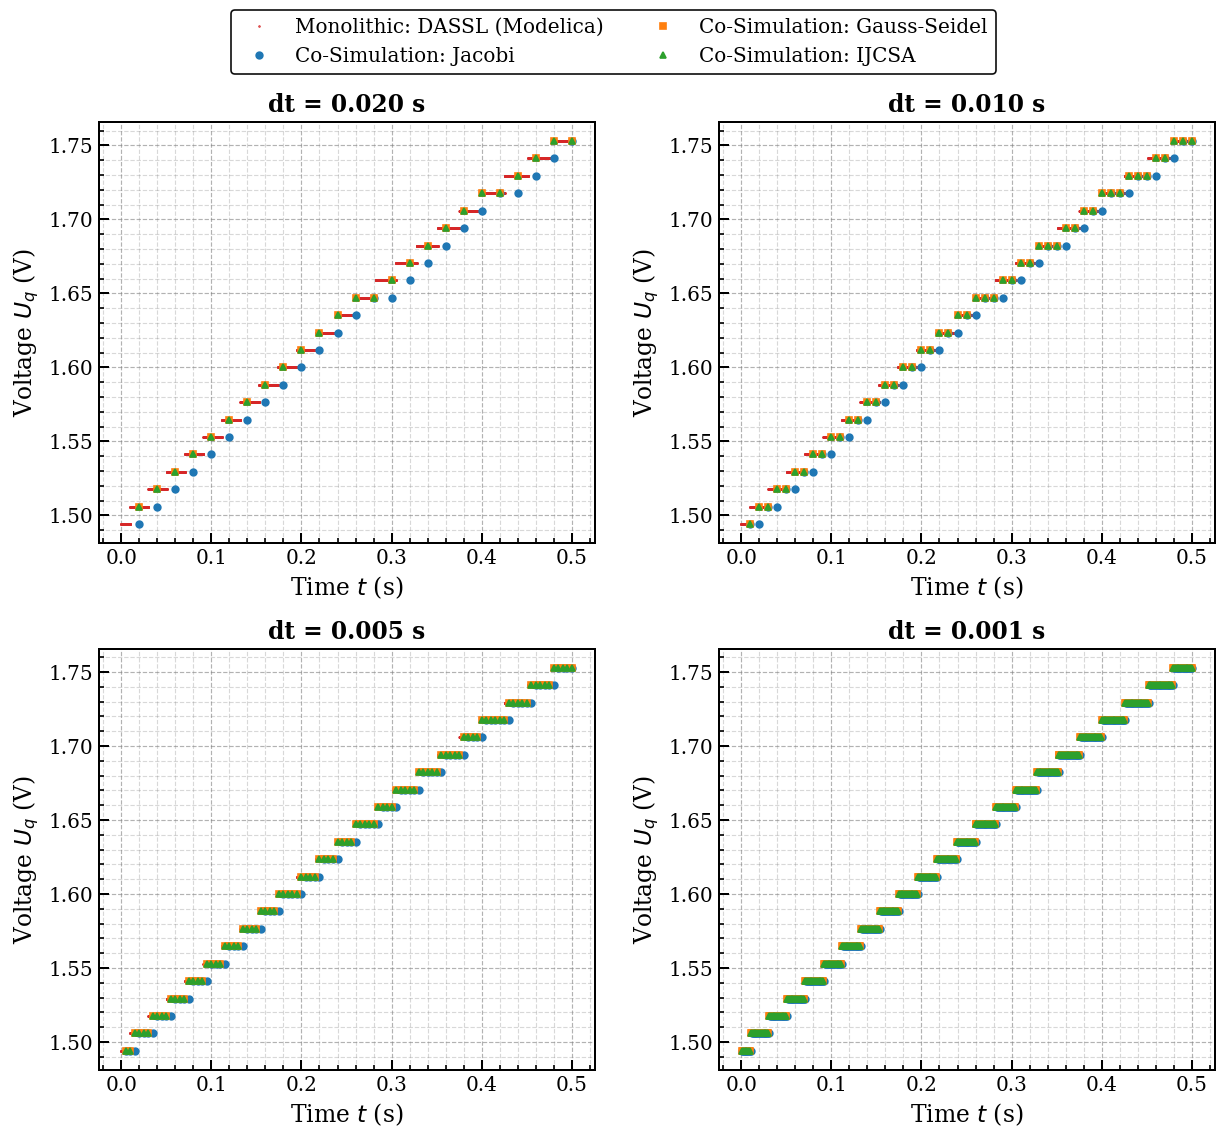

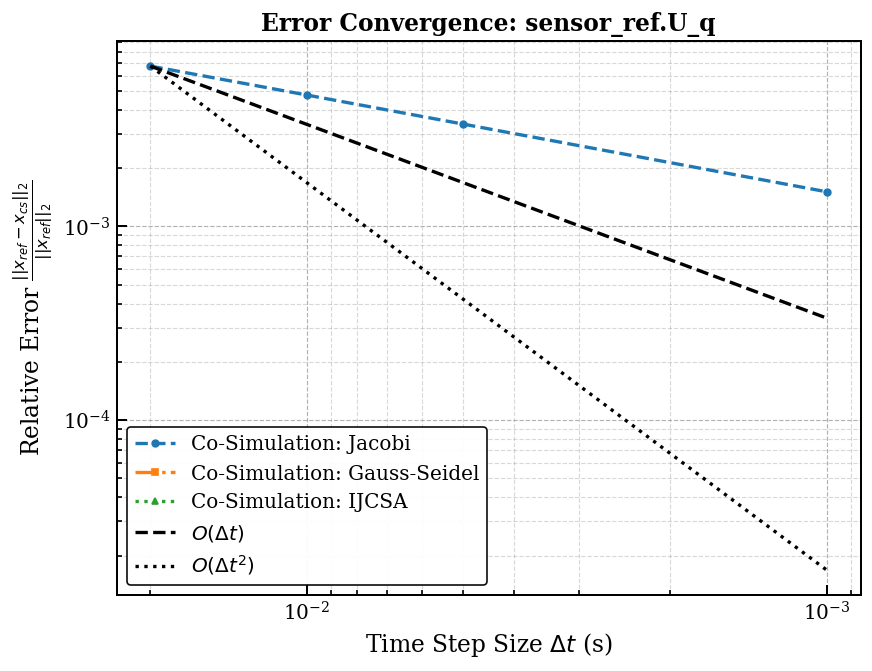

In [145]:
monolithic_signal = 'sensor_ref.U_q'
cs_signal = monolithic_signal
y_label = r'Voltage $U_q$ (V)'

create_trajectory_plot(monolithic_signal, cs_signal, y_label)
create_error_convergence_plot(monolithic_signal, cs_signal)

#### 2.3 Pendulum Sensor

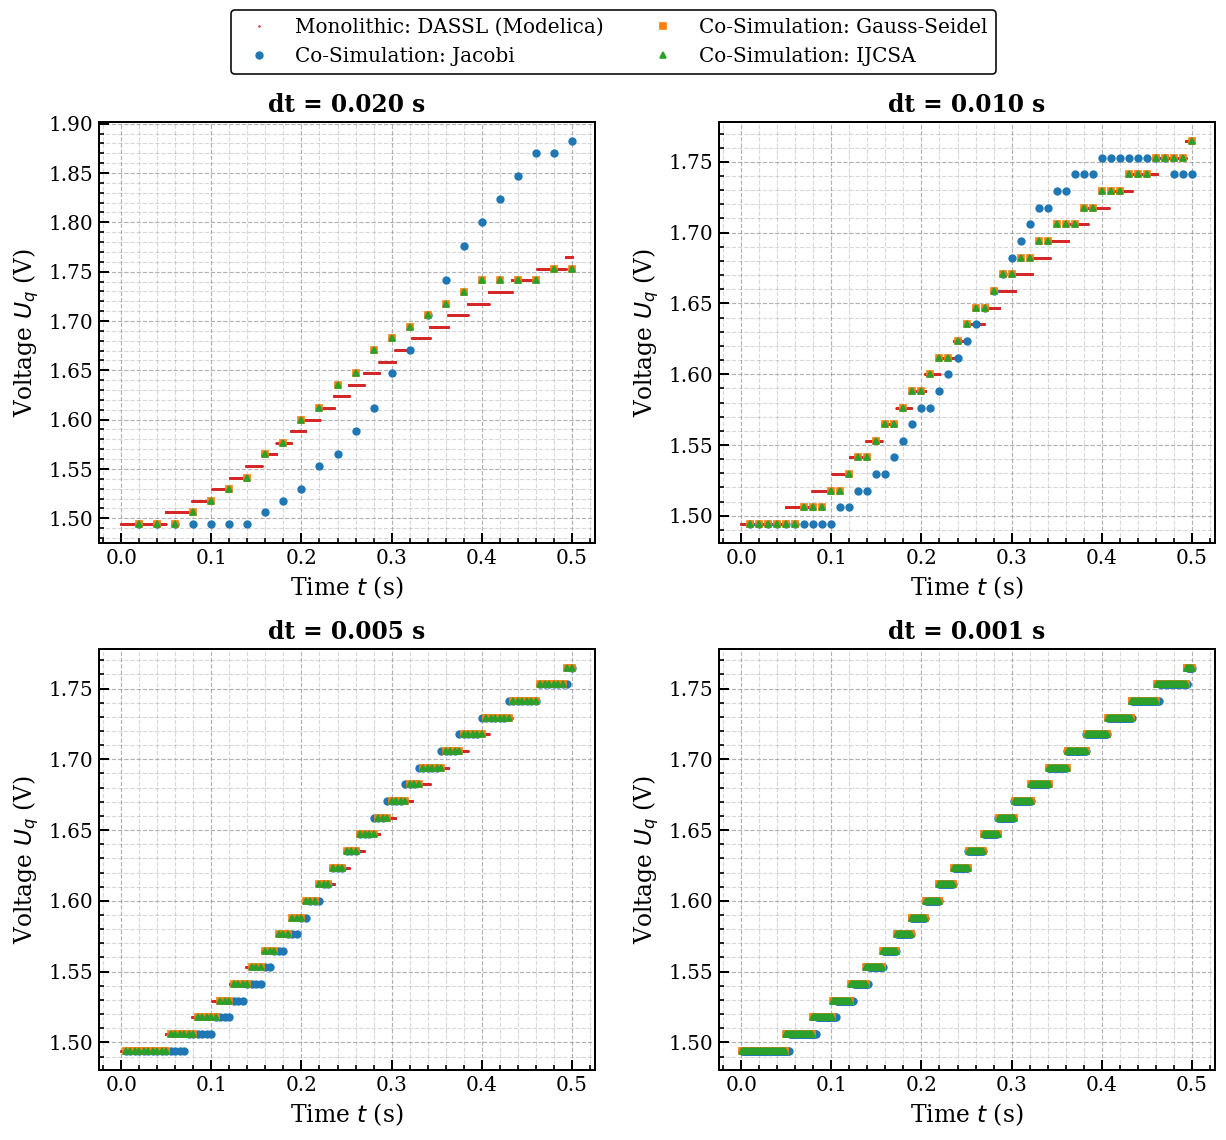

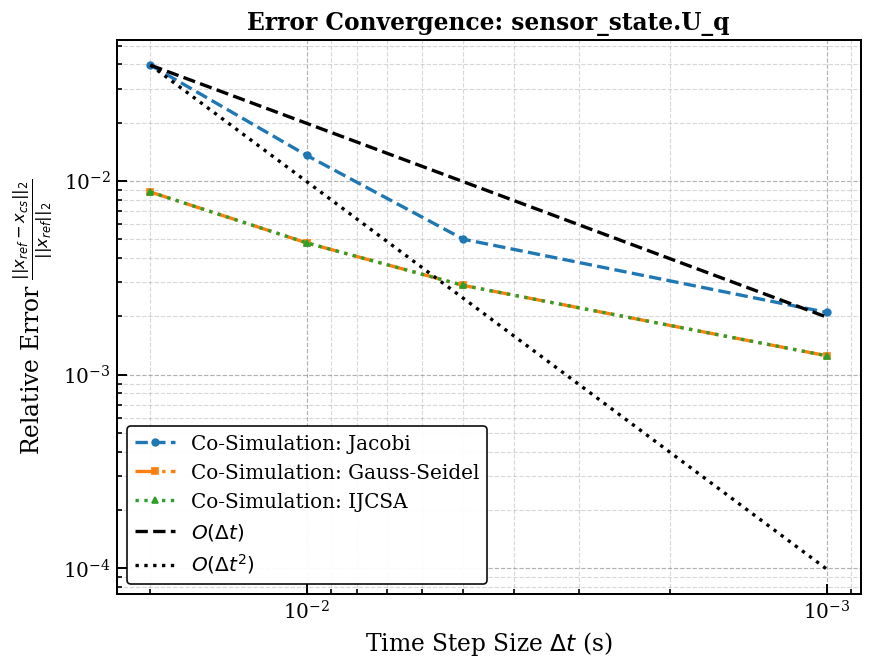

In [146]:
monolithic_signal = 'sensor_state.U_q'
cs_signal = monolithic_signal
y_label = r'Voltage $U_q$ (V)'

create_trajectory_plot(monolithic_signal, cs_signal, y_label)
create_error_convergence_plot(monolithic_signal, cs_signal)

#### 2.4 PID Controller

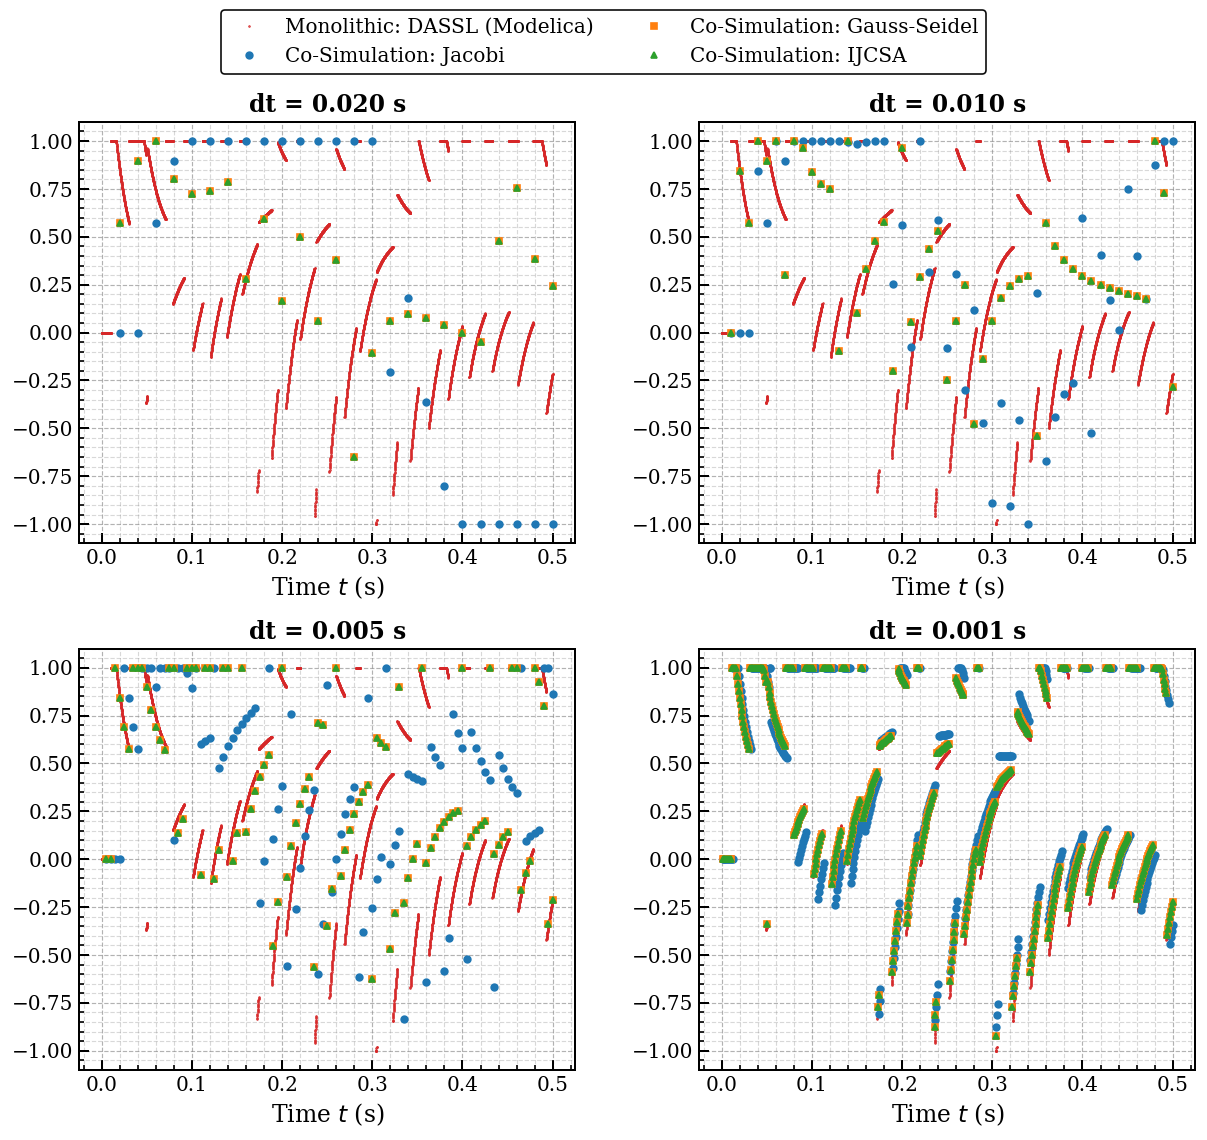

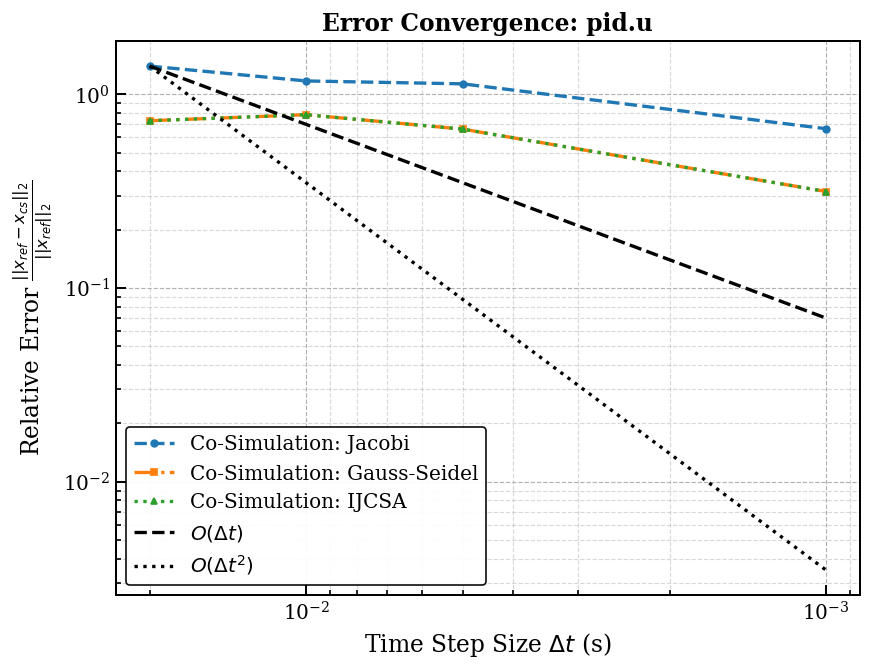

In [144]:
monolithic_signal = 'pid.u'
cs_signal = monolithic_signal
y_label = ''

create_trajectory_plot(monolithic_signal, cs_signal, y_label)
create_error_convergence_plot(monolithic_signal, cs_signal)

#### 2.5 Drive

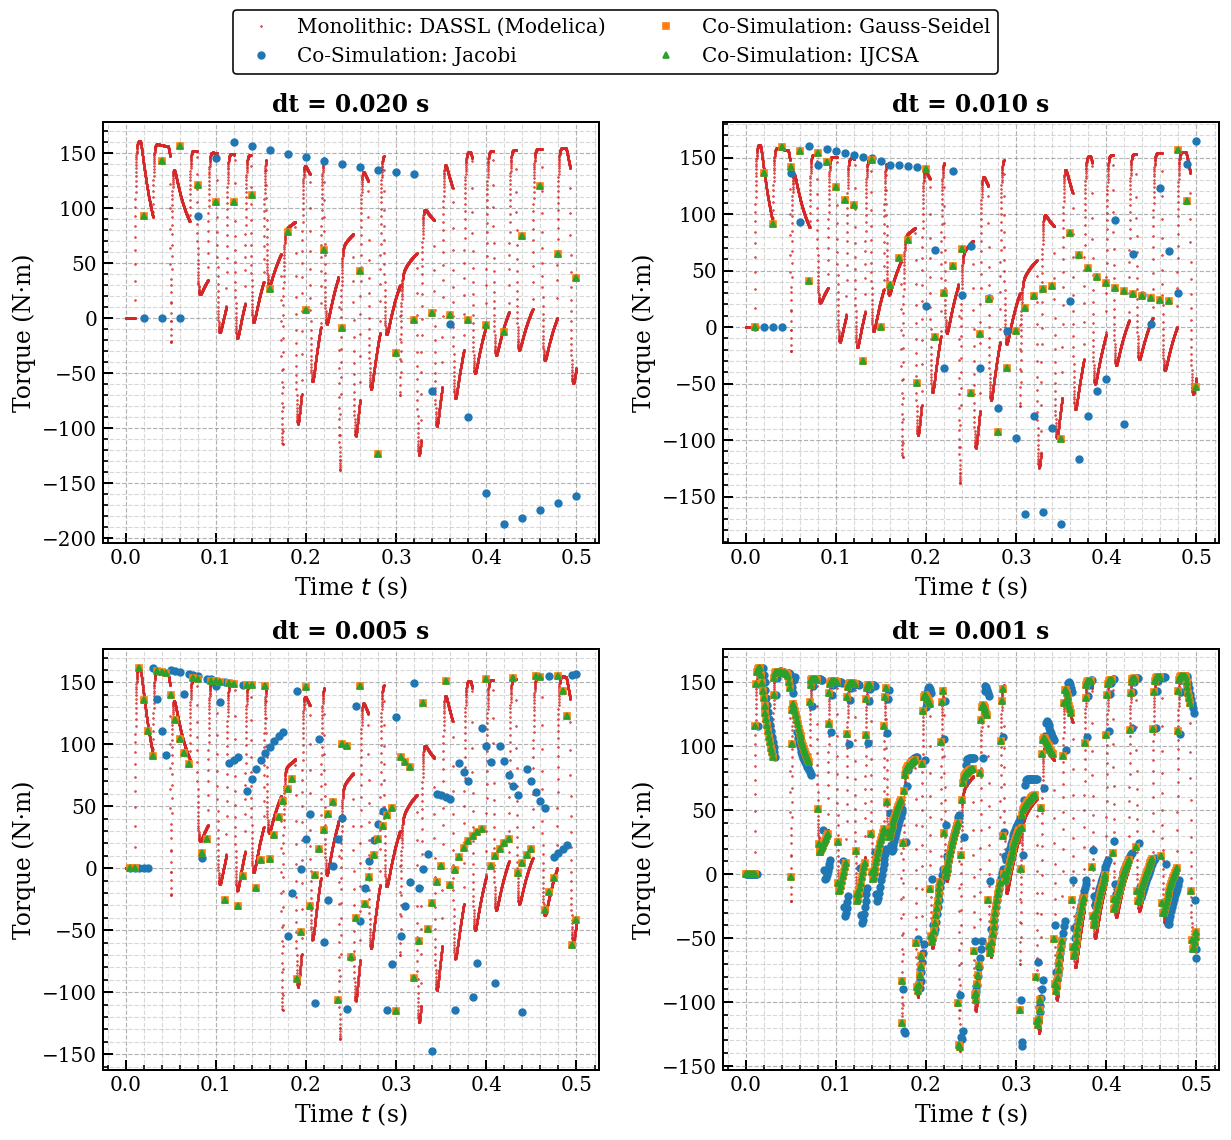

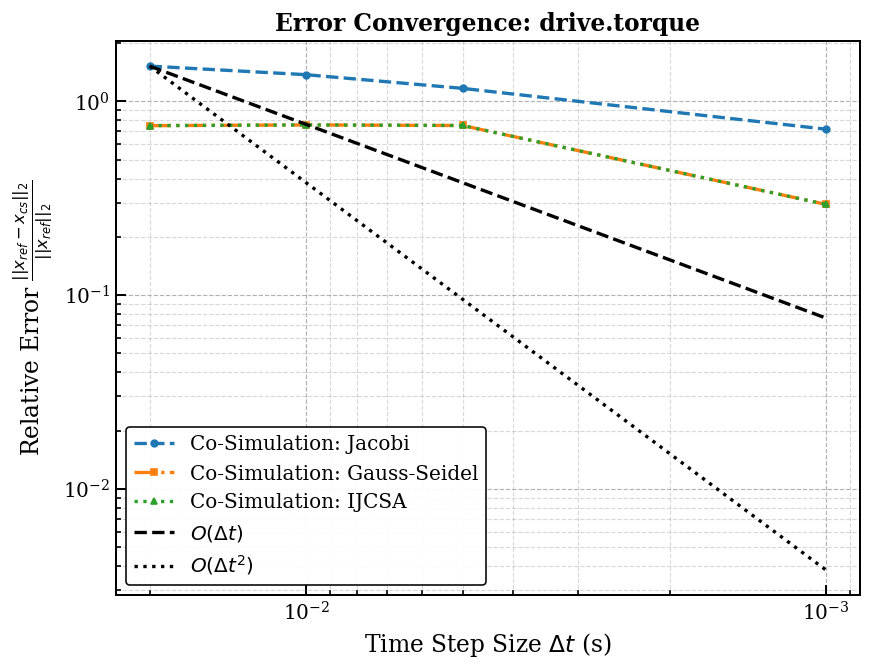

In [143]:
monolithic_signal = 'drive.torque'
cs_signal = monolithic_signal
y_label = 'Torque (N·m)'

create_trajectory_plot(monolithic_signal, cs_signal, y_label)
create_error_convergence_plot(monolithic_signal, cs_signal)

#### 2.6 Pendulum

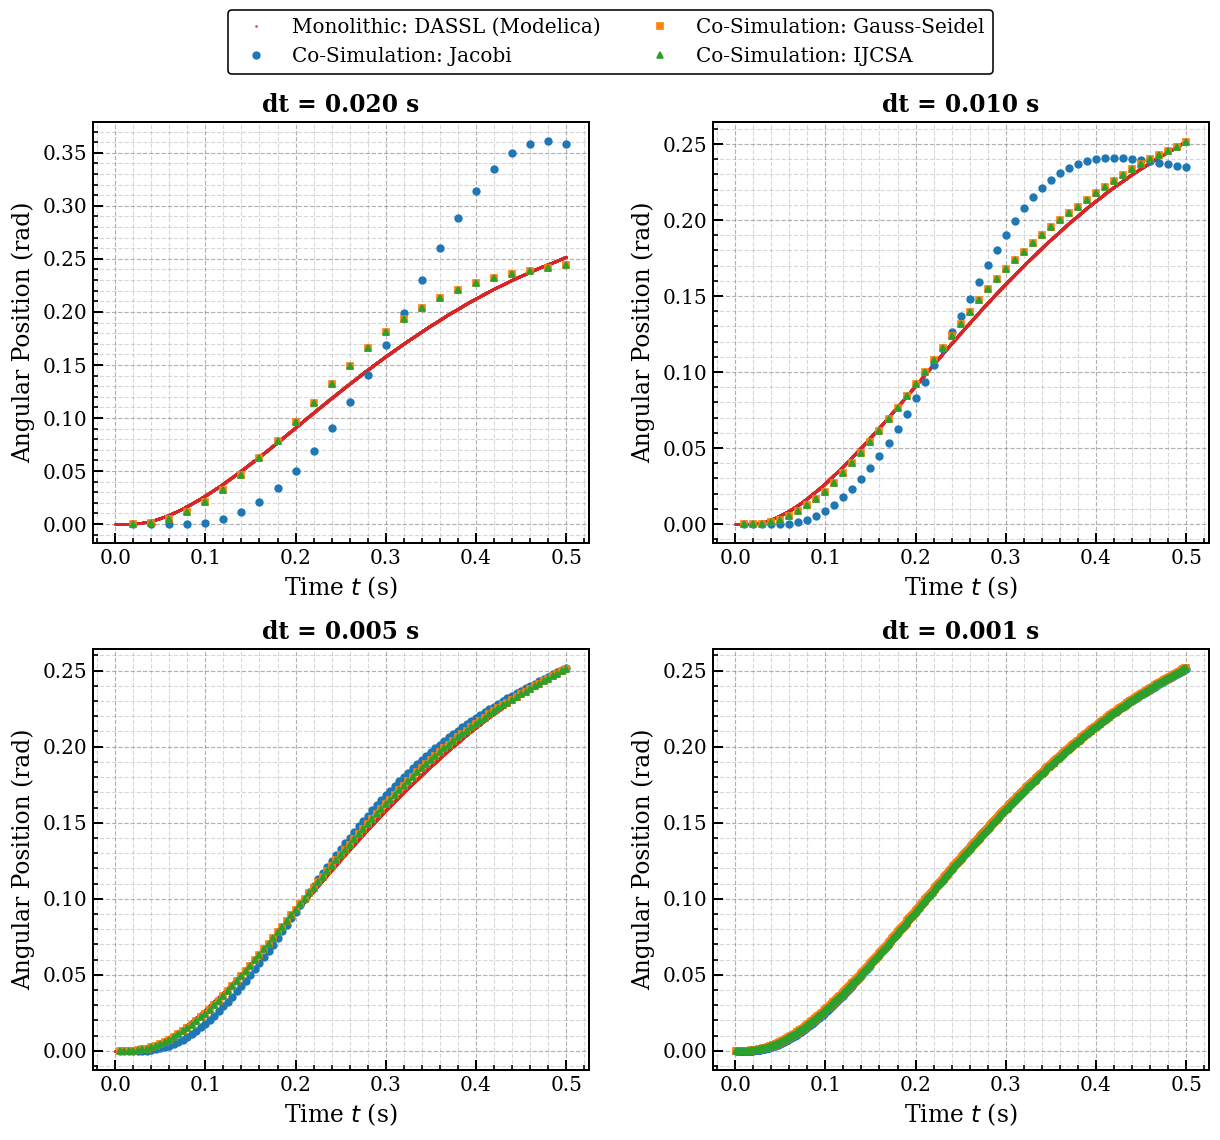

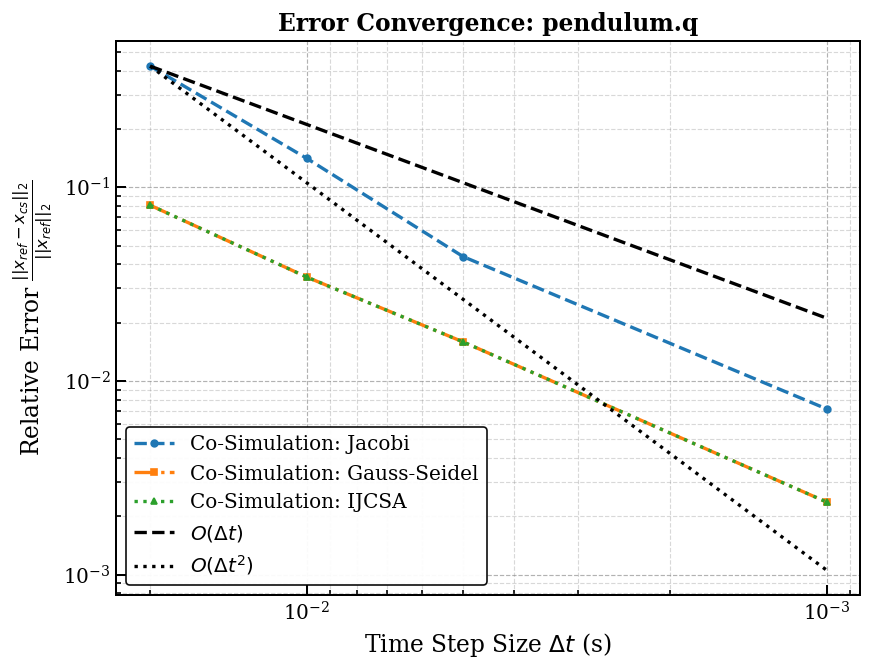

In [ ]:
monolithic_signal = 'pendulum.q'
cs_signal = monolithic_signal
y_label = 'Angular Position (rad)' 

create_trajectory_plot(monolithic_signal, cs_signal, y_label)
create_error_convergence_plot(monolithic_signal, cs_signal)

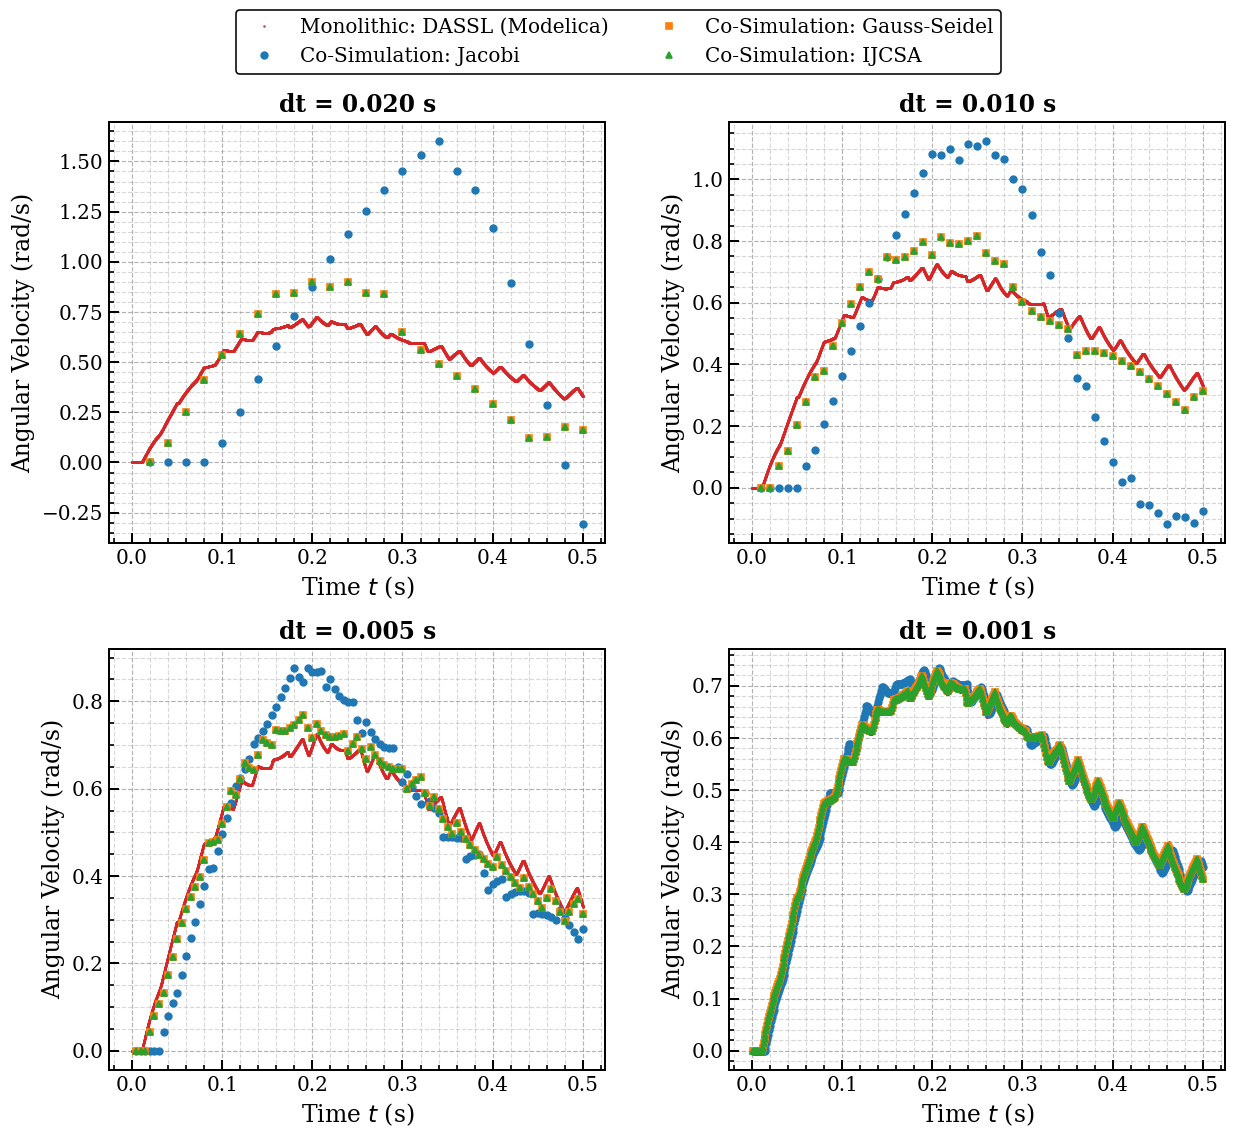

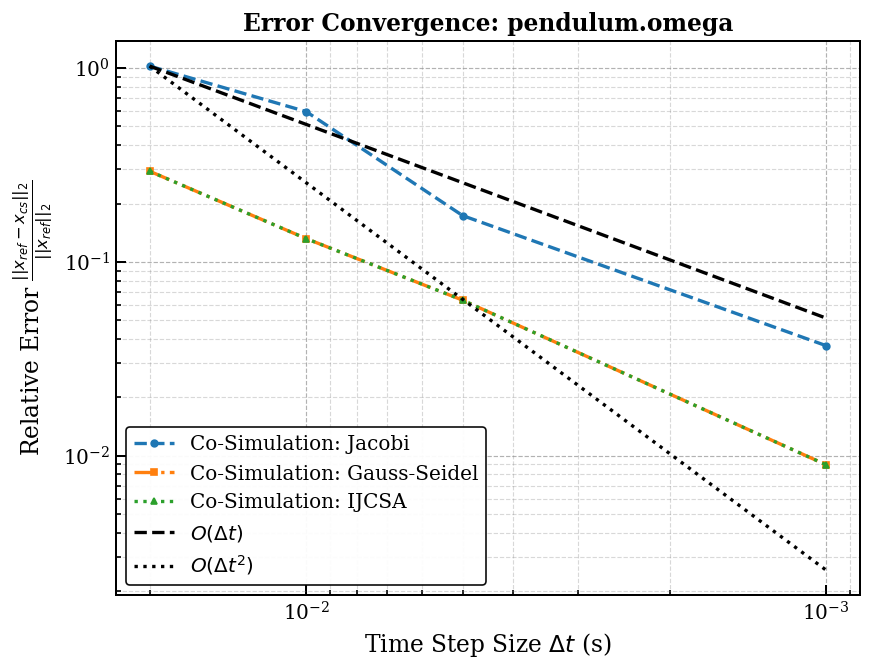

In [140]:
monolithic_signal = 'pendulum.omega'
cs_signal = monolithic_signal
y_label = 'Angular Velocity (rad/s)'

create_trajectory_plot(monolithic_signal, cs_signal, y_label)
create_error_convergence_plot(monolithic_signal, cs_signal)

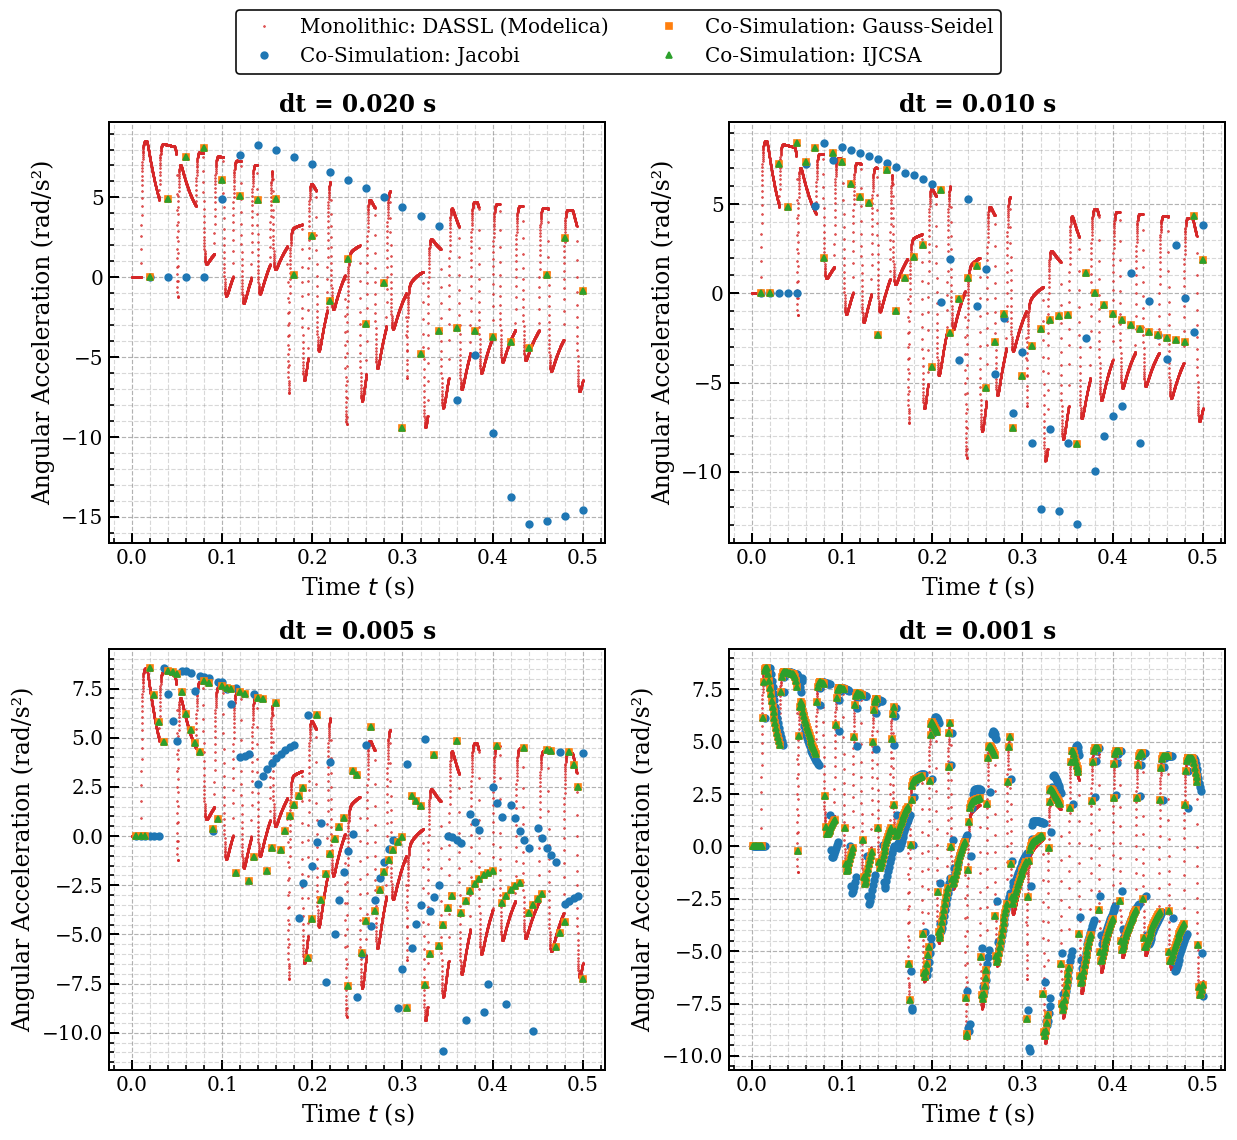

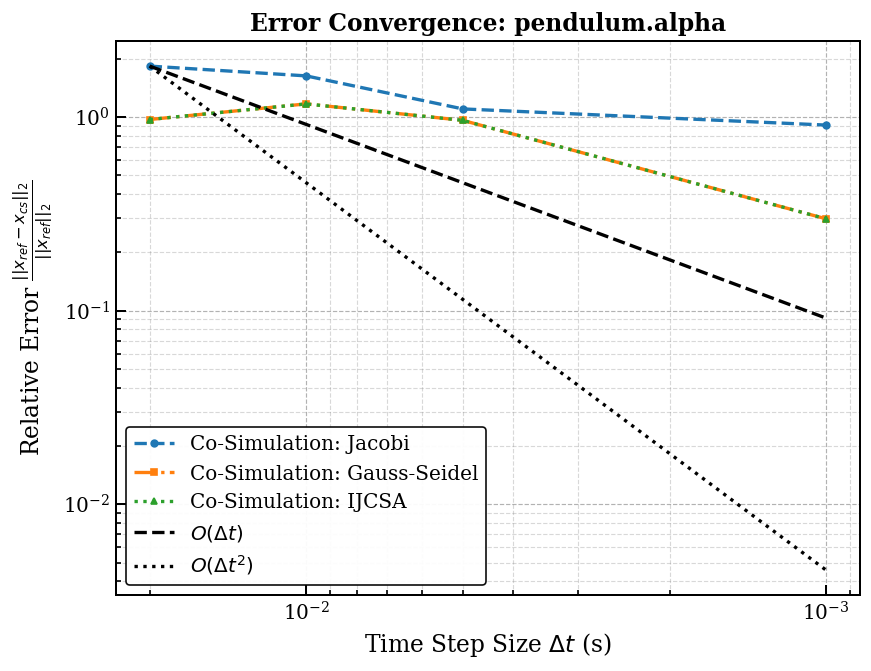

In [139]:
monolithic_signal = 'pendulum.alpha'
cs_signal = monolithic_signal
y_label = 'Angular Acceleration (rad/s²)'

create_trajectory_plot(monolithic_signal, cs_signal, y_label)
create_error_convergence_plot(monolithic_signal, cs_signal)